In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Calibo\Phase-2\ML\Supervised\Business Use case\Cleaned_Customer_Churn.csv")

df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22,23800,11,62.96,7,20.4,5,Monthly,Bank Transfer,North,Standard,Yes
1,CUST-1043,35,69400,17,75.63,6,17.5,9,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55,64400,49,92.85,3,21.6,1,Monthly,Upi,West,Basic,Yes
3,CUST-1112,36,80000,9,85.67,0,34.3,9,Monthly,Upi,South,Standard,Yes
4,CUST-1149,41,95700,51,60.77,1,23.7,9,Monthly,Debit Card,West,Premium,Yes


In [3]:
df.dtypes

Customer_ID               object
Age                        int64
Annual_Income              int64
Tenure_Months              int64
Monthly_Charges          float64
Support_Calls_Last_3M      int64
Data_Usage_GB            float64
Satisfaction_Score         int64
Contract_Type             object
Payment_Method            object
Region                    object
Plan_Type                 object
Churn                     object
dtype: object

In [4]:
df.shape

(180, 13)

In [5]:
df.describe()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,180.000000,1.800000e+02,180.000000,180.000000,180.000000,180.000000,180.000000
mean,36.111111,1.195150e+05,39.250000,79.654833,3.205556,17.816667,5.811111
std,12.705468,7.409227e+05,21.076046,73.713884,2.558144,9.141449,2.894396
min,-5.000000,-1.200000e+04,1.000000,0.000000,0.000000,-10.000000,1.000000
25%,29.750000,5.055000e+04,25.000000,58.035000,2.000000,12.050000,4.000000
50%,36.000000,6.440000e+04,38.000000,72.945000,3.000000,18.200000,6.000000
75%,41.000000,7.680000e+04,54.000000,89.042500,4.000000,24.125000,8.000000
max,145.000000,9.999999e+06,150.000000,999.000000,30.000000,44.000000,15.000000


In [6]:
# Store the target variable

y = df['Churn']

# Remove Customer_ID and Churn from the feature dataset

X = df.drop(columns=['Customer_ID', 'Churn'])

X.head()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type
0,22,23800,11,62.96,7,20.4,5,Monthly,Bank Transfer,North,Standard
1,35,69400,17,75.63,6,17.5,9,Monthly,Bank Transfer,South,Basic
2,55,64400,49,92.85,3,21.6,1,Monthly,Upi,West,Basic
3,36,80000,9,85.67,0,34.3,9,Monthly,Upi,South,Standard
4,41,95700,51,60.77,1,23.7,9,Monthly,Debit Card,West,Premium


In [7]:
# Select numerical columns

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

numerical_features

['Age',
 'Annual_Income',
 'Tenure_Months',
 'Monthly_Charges',
 'Support_Calls_Last_3M',
 'Data_Usage_GB',
 'Satisfaction_Score']

In [8]:
# Select categorical columns

categorical_features = X.select_dtypes(
    include='object'
).columns.tolist()

categorical_features

['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

In [9]:
# Check missing values in numerical features

X[numerical_features].isnull().sum()

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64

In [10]:
# Check missing values in categorical features

X[categorical_features].isnull().sum()

Contract_Type     0
Payment_Method    0
Region            0
Plan_Type         0
dtype: int64

In [11]:
# Select numerical columns

numerical_df = df.select_dtypes(include=np.number)

# Calculate correlation

correlation = numerical_df.corr()

correlation

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Age,1.000000,0.006161,0.009242,-0.010183,-0.031130,-0.033460,-0.040291
Annual_Income,0.006161,1.000000,-0.119801,0.011492,0.025274,-0.095589,0.085682
Tenure_Months,0.009242,-0.119801,1.000000,-0.012276,-0.019402,0.002826,0.025597
Monthly_Charges,-0.010183,0.011492,-0.012276,1.000000,0.023744,-0.002669,0.108406
Support_Calls_Last_3M,-0.031130,0.025274,-0.019402,0.023744,1.000000,-0.033688,-0.043770
Data_Usage_GB,-0.033460,-0.095589,0.002826,-0.002669,-0.033688,1.000000,0.070852
Satisfaction_Score,-0.040291,0.085682,0.025597,0.108406,-0.043770,0.070852,1.000000


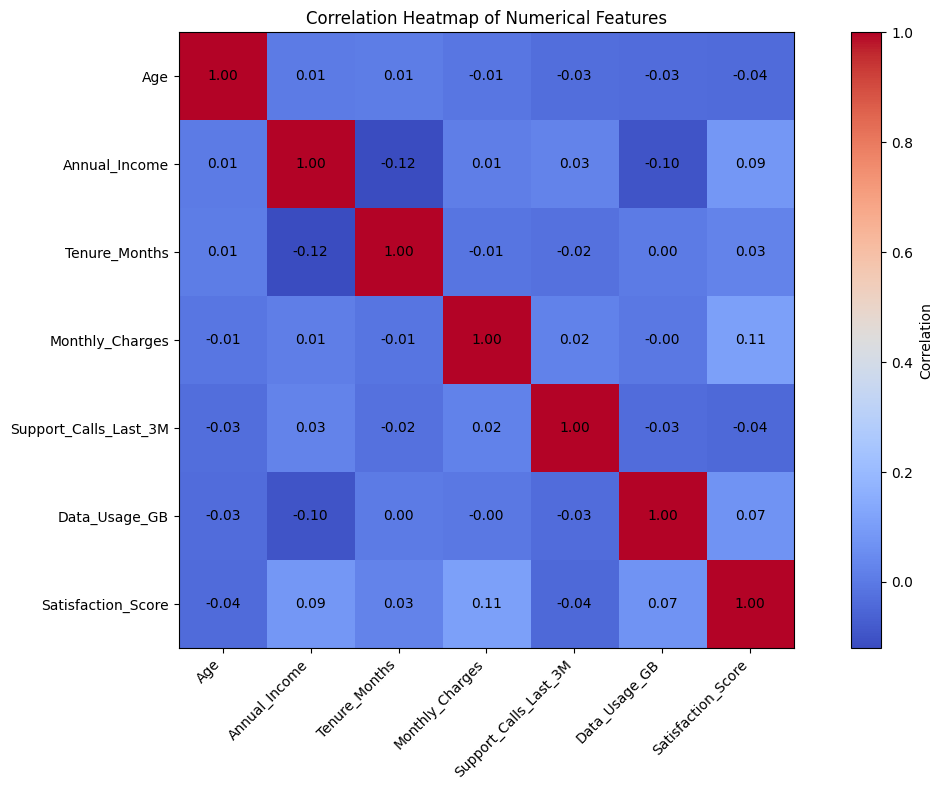

In [12]:
# Create correlation heatmap

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation,
    cmap='coolwarm',
    interpolation='nearest'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

# Display correlation values

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f'{correlation.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [13]:
# Count customers in each churn category

churn_count = y.value_counts()

churn_count

Churn
Yes    94
No     86
Name: count, dtype: int64

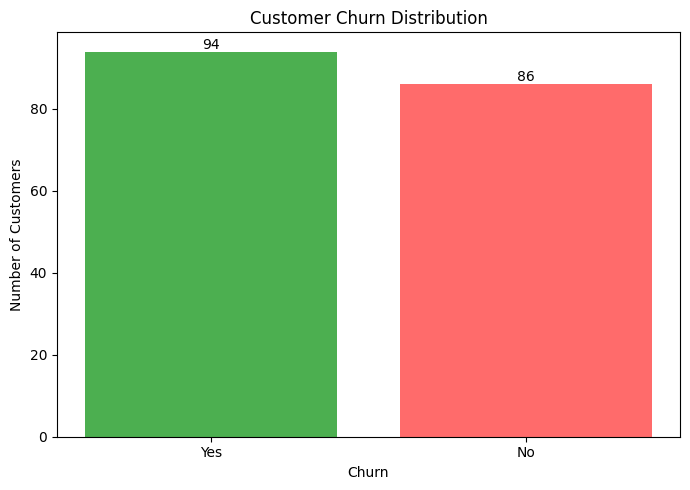

In [14]:
# Plot churn distribution

plt.figure(figsize=(7, 5))

bars = plt.bar(
    churn_count.index,
    churn_count.values,
    color=['#4CAF50', '#FF6B6B']
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.bar_label(bars)

plt.tight_layout()
plt.show()

In [15]:
# Calculate churn percentage

churn_percentage = y.value_counts(normalize=True) * 100

churn_percentage

Churn
Yes    52.222222
No     47.777778
Name: proportion, dtype: float64

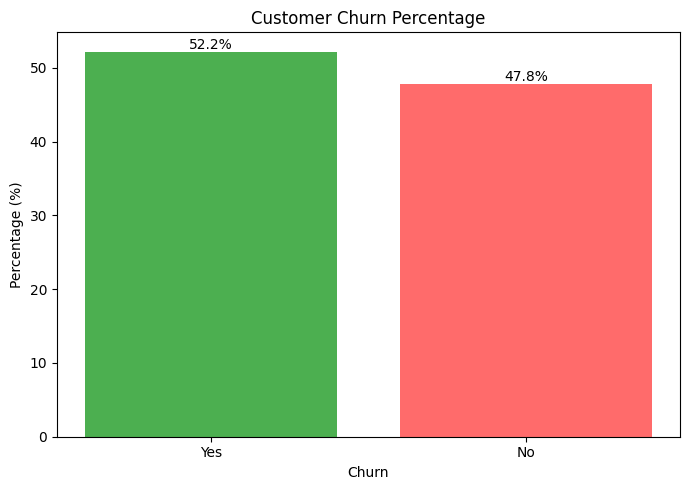

In [16]:
# Plot churn percentage

plt.figure(figsize=(7, 5))

bars = plt.bar(
    churn_percentage.index,
    churn_percentage.values,
    color=['#4CAF50', '#FF6B6B']
)

plt.title('Customer Churn Percentage')
plt.xlabel('Churn')
plt.ylabel('Percentage (%)')

plt.bar_label(
    bars,
    fmt='%.1f%%'
)

plt.tight_layout()
plt.show()

In [17]:
# Calculate churn percentage by contract type

contract_churn = pd.crosstab(
    df['Contract_Type'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract_Type,,
1 Year,53.846154,46.153846
2 Year,82.608696,17.391304
2-Year,0.000000,100.000000
Monthly,37.500000,62.500000


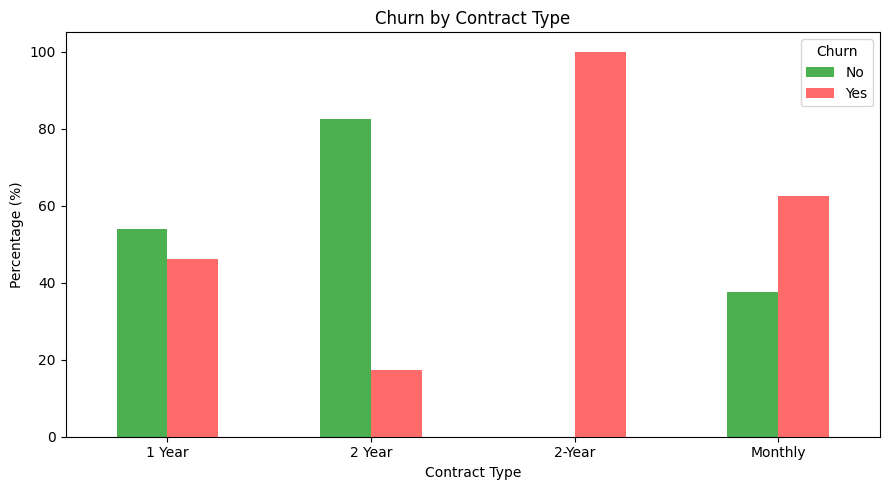

In [18]:
# Plot churn by contract type

contract_churn.plot(
    kind='bar',
    figsize=(9, 5),
    color=['#4CAF50', '#FF6B6B']
)

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')

plt.tight_layout()
plt.show()

In [19]:
# Calculate churn percentage for each satisfaction score

satisfaction_churn = pd.crosstab(
    df['Satisfaction_Score'],
    df['Churn'],
    normalize='index'
) * 100

satisfaction_churn

Churn,No,Yes
Satisfaction_Score,,
1,31.578947,68.421053
2,54.545455,45.454545
3,30.769231,69.230769
4,44.444444,55.555556
5,33.333333,66.666667
6,50.000000,50.000000
7,56.250000,43.750000
8,50.000000,50.000000
9,56.521739,43.478261


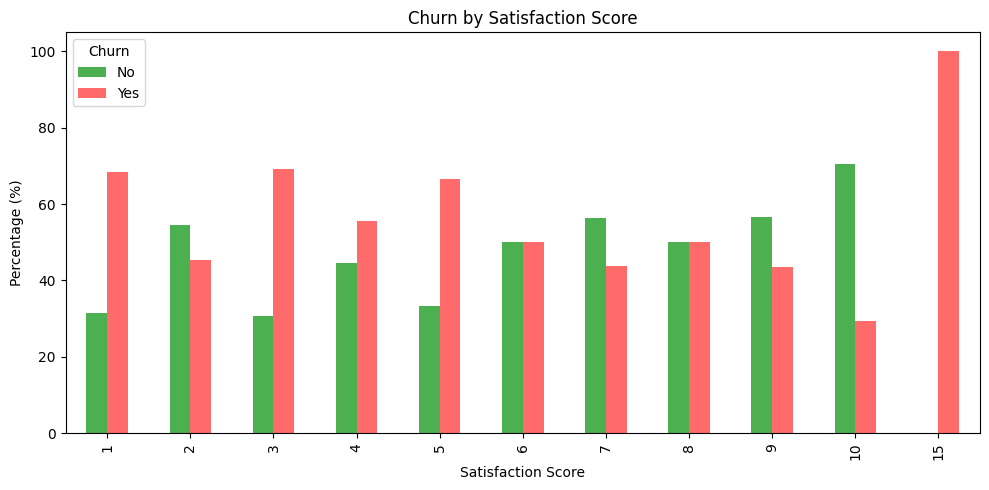

In [20]:
# Plot satisfaction score against churn

satisfaction_churn.plot(
    kind='bar',
    figsize=(10, 5),
    color=['#4CAF50', '#FF6B6B']
)

plt.title('Churn by Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn')

plt.tight_layout()
plt.show()

In [21]:
# Compare tenure for churn and non-churn customers

df.groupby('Churn')['Tenure_Months'].mean()

Churn
No     37.930233
Yes    40.457447
Name: Tenure_Months, dtype: float64

<Figure size 800x500 with 0 Axes>

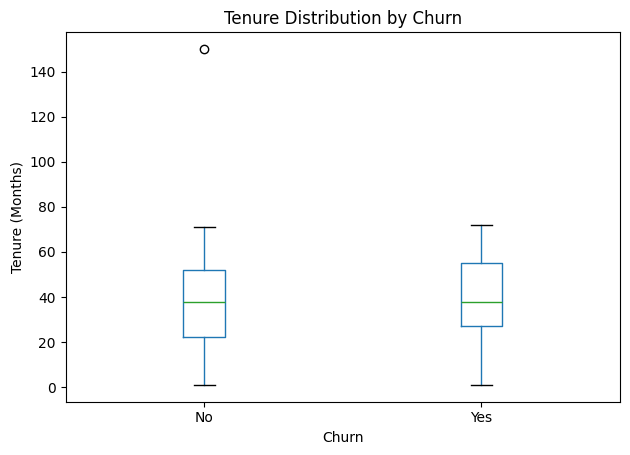

In [22]:
# Plot tenure distribution by churn

plt.figure(figsize=(8, 5))

df.boxplot(
    column='Tenure_Months',
    by='Churn',
    grid=False
)

plt.title('Tenure Distribution by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.tight_layout()
plt.show()

In [23]:
# Compare monthly charges for churn and non-churn customers

df.groupby('Churn')['Monthly_Charges'].mean()

Churn
No     72.651860
Yes    86.061809
Name: Monthly_Charges, dtype: float64

<Figure size 800x500 with 0 Axes>

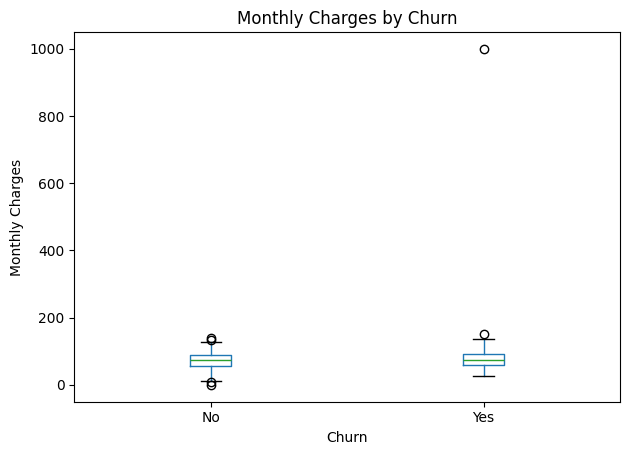

In [24]:
# Plot monthly charges by churn

plt.figure(figsize=(8, 5))

df.boxplot(
    column='Monthly_Charges',
    by='Churn',
    grid=False
)

plt.title('Monthly Charges by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.tight_layout()
plt.show()

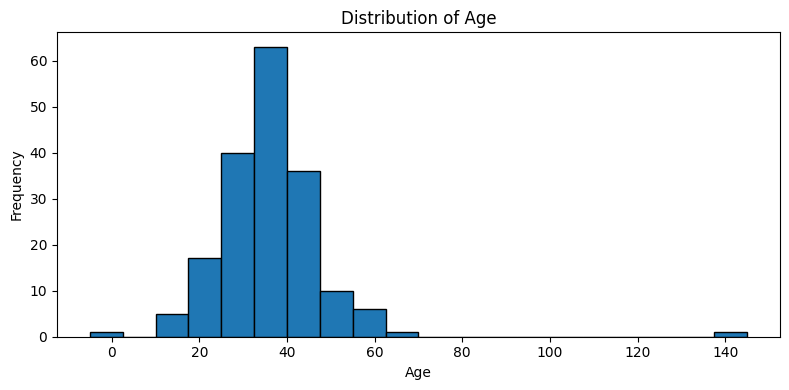

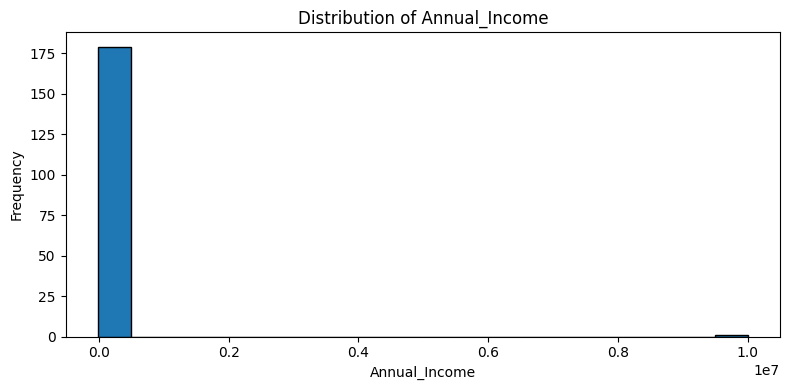

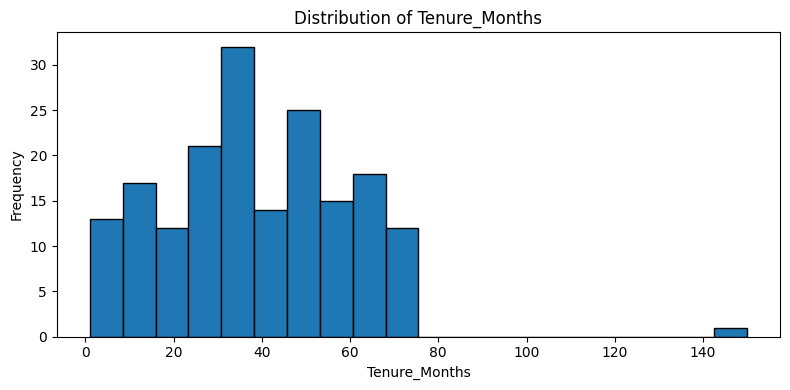

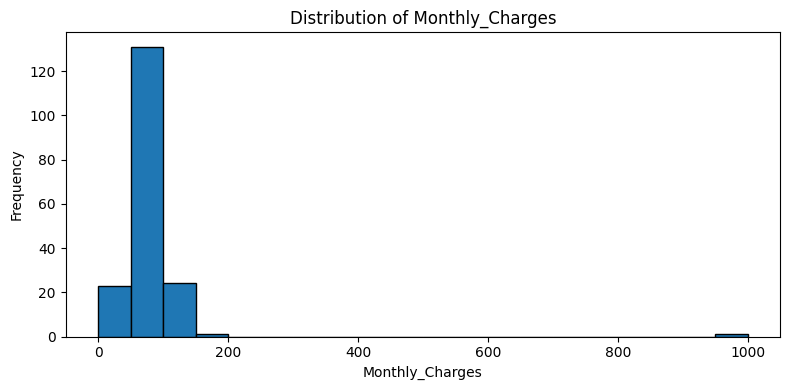

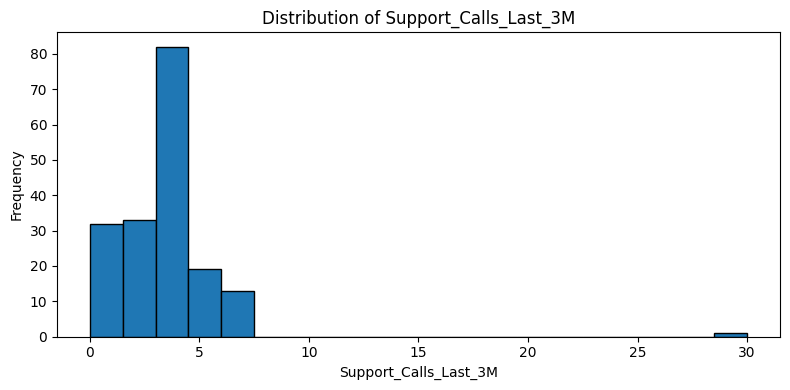

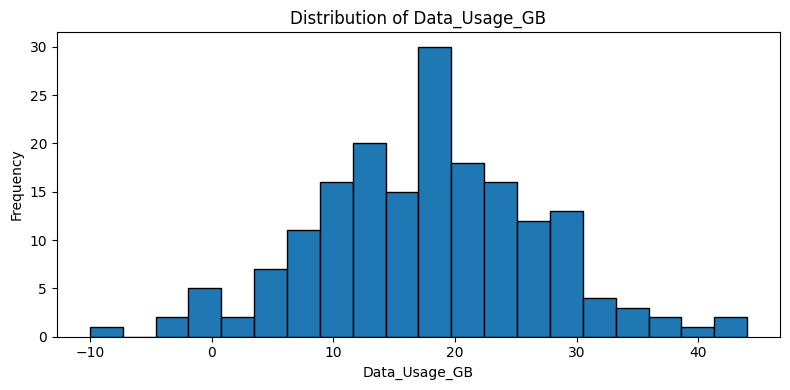

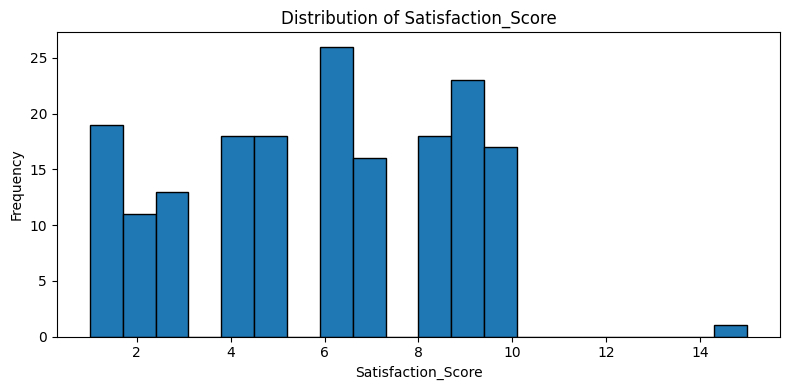

In [25]:
# Plot numerical feature distributions

for column in numerical_features:
    
    plt.figure(figsize=(8, 4))
    
    plt.hist(
        X[column],
        bins=20,
        edgecolor='black'
    )
    
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

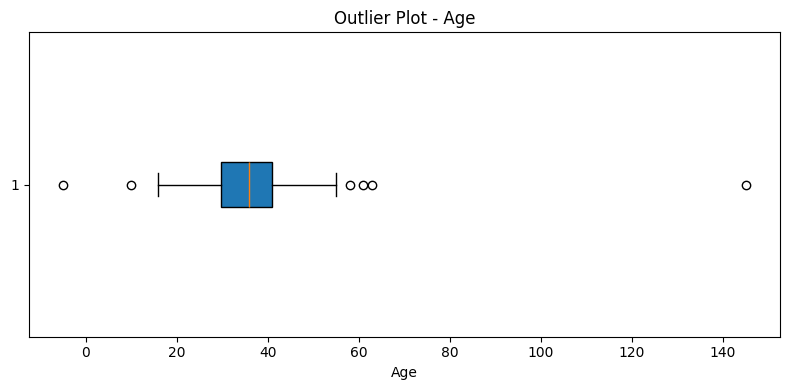

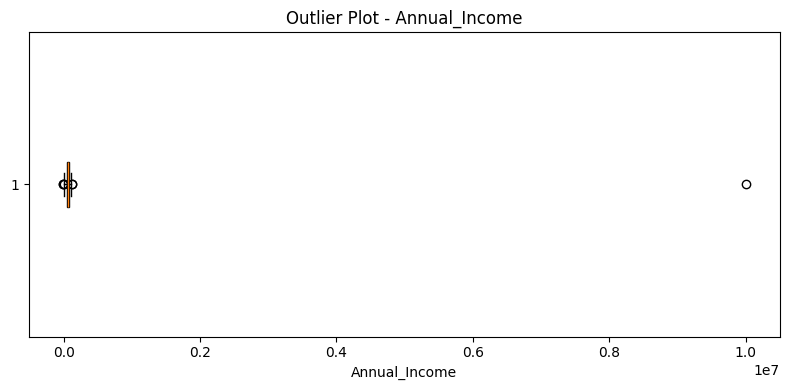

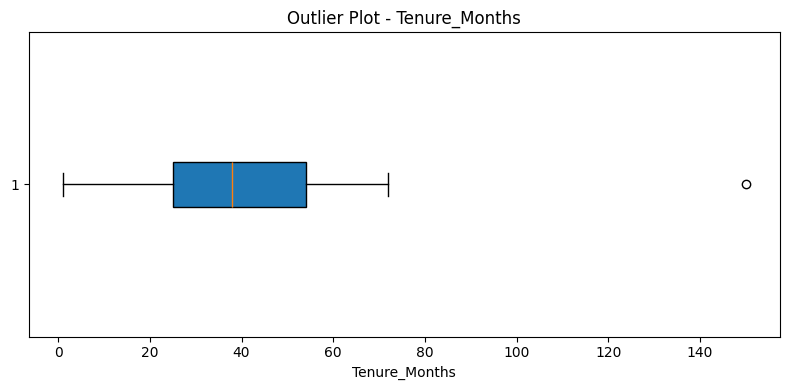

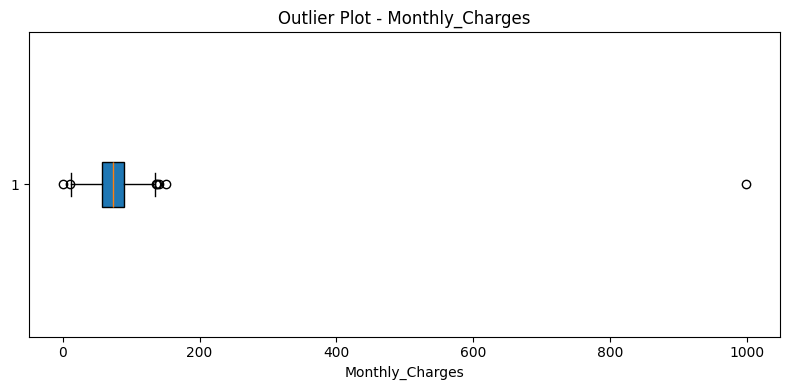

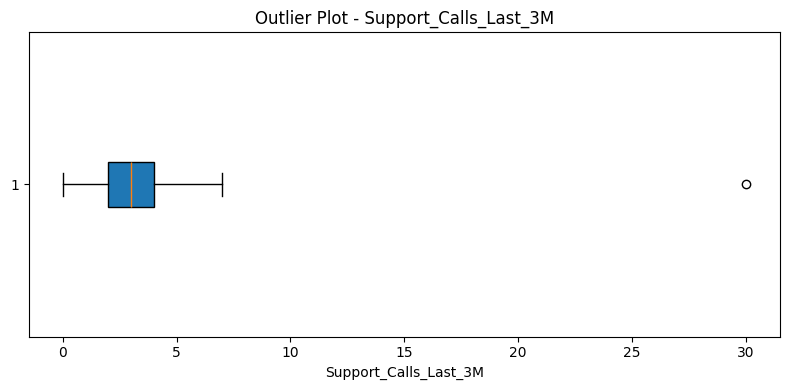

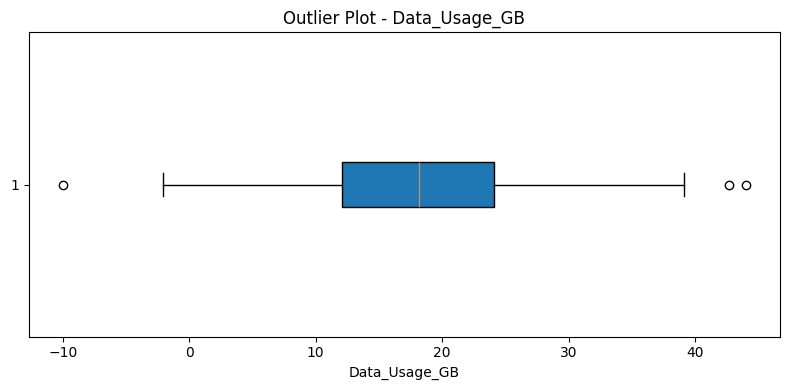

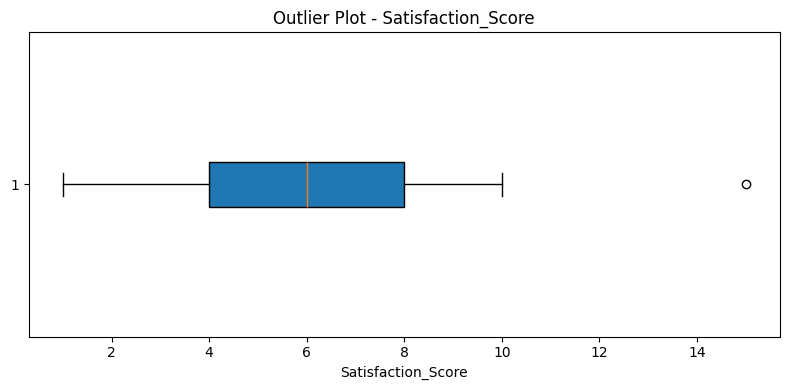

In [26]:
# Plot box plots to identify outliers

for column in numerical_features:
    
    plt.figure(figsize=(8, 4))
    
    plt.boxplot(
        X[column].dropna(),
        vert=False,
        patch_artist=True
    )
    
    plt.title(f'Outlier Plot - {column}')
    plt.xlabel(column)
    
    plt.tight_layout()
    plt.show()

In [27]:
# Calculate outlier counts using the IQR method

outlier_counts = {}

for column in numerical_features:
    
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = X[
        (X[column] < lower_limit) |
        (X[column] > upper_limit)
    ]
    
    outlier_counts[column] = len(outliers)

outlier_counts

{'Age': 6,
 'Annual_Income': 6,
 'Tenure_Months': 1,
 'Monthly_Charges': 7,
 'Support_Calls_Last_3M': 1,
 'Data_Usage_GB': 3,
 'Satisfaction_Score': 1}

In [28]:
# Convert categorical variables into dummy variables

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

X_encoded.head()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type_2 Year,Contract_Type_2-Year,Contract_Type_Monthly,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Unknown,Payment_Method_Upi,Region_North,Region_South,Region_West,Plan_Type_Premium,Plan_Type_Standard
0,22,23800,11,62.96,7,20.4,5,False,False,True,False,False,False,False,True,False,False,False,True
1,35,69400,17,75.63,6,17.5,9,False,False,True,False,False,False,False,False,True,False,False,False
2,55,64400,49,92.85,3,21.6,1,False,False,True,False,False,False,True,False,False,True,False,False
3,36,80000,9,85.67,0,34.3,9,False,False,True,False,False,False,True,False,True,False,False,True
4,41,95700,51,60.77,1,23.7,9,False,False,True,False,True,False,False,False,False,True,True,False


In [29]:
# Check the number of features after encoding

X_encoded.shape

(180, 19)

In [30]:
# Feature Scaling using Standardization

# Select numerical columns
numerical_columns = X_encoded.select_dtypes(
    include=np.number
).columns

# Create a copy of the encoded dataset
X_scaled = X_encoded.copy()

# Apply standardization
X_scaled[numerical_columns] = (
    X_scaled[numerical_columns]
    - X_scaled[numerical_columns].mean()
) / X_scaled[numerical_columns].std()

X_scaled.head()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type_2 Year,Contract_Type_2-Year,Contract_Type_Monthly,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Unknown,Payment_Method_Upi,Region_North,Region_South,Region_West,Plan_Type_Premium,Plan_Type_Standard
0,-1.110633,-0.129184,-1.340384,-0.226482,1.483280,0.282596,-0.280235,False,False,True,False,False,False,False,True,False,False,False,True
1,-0.087451,-0.067639,-1.055701,-0.054601,1.092372,-0.034641,1.101746,False,False,True,False,False,False,False,False,True,False,False,False
2,1.486674,-0.074387,0.462610,0.179005,-0.080353,0.413866,-1.662216,False,False,True,False,False,False,True,False,False,True,False,False
3,-0.008745,-0.053332,-1.435279,0.081602,-1.253078,1.803142,1.101746,False,False,True,False,False,False,True,False,True,False,False,True
4,0.384786,-0.032142,0.557505,-0.256191,-0.862170,0.643589,1.101746,False,False,True,False,True,False,False,False,False,True,True,False


In [31]:
# Check mean and standard deviation after scaling

# Check mean and standard deviation after scaling

X_scaled[numerical_columns].agg(
    ['mean', 'std']
)

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
mean,-2.319133e-16,-2.467162e-17,-1.233581e-18,5.921189e-17,-7.894919e-17,4.280527e-16,8.388352e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


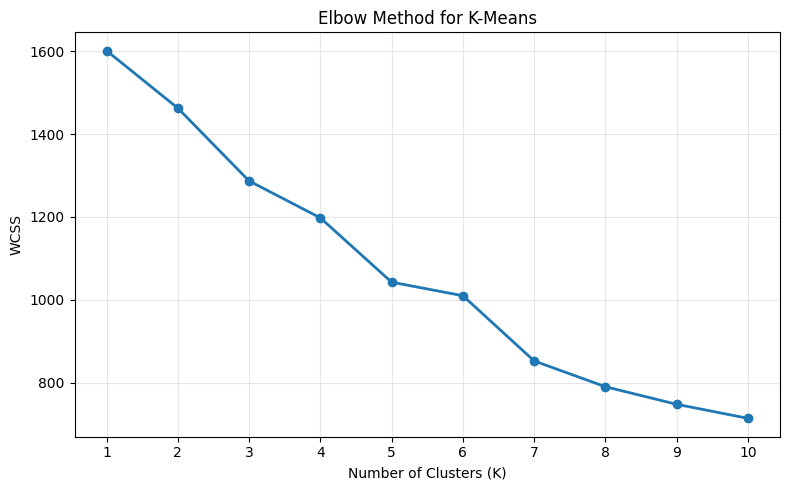

In [32]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o',
    linewidth=2
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for K-Means')

plt.xticks(range(1, 11))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# K-Means

In [40]:
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans_clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_clusters

df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn,Cluster,Hierarchical_Cluster,DBSCAN_Cluster,KMeans_Cluster
0,CUST-1020,22,23800,11,62.96,7,20.4,5,Monthly,Bank Transfer,North,Standard,Yes,0,0,-1,0
1,CUST-1043,35,69400,17,75.63,6,17.5,9,Monthly,Bank Transfer,South,Basic,Yes,0,0,-1,0
2,CUST-1157,55,64400,49,92.85,3,21.6,1,Monthly,Upi,West,Basic,Yes,2,0,-1,2
3,CUST-1112,36,80000,9,85.67,0,34.3,9,Monthly,Upi,South,Standard,Yes,0,0,-1,0
4,CUST-1149,41,95700,51,60.77,1,23.7,9,Monthly,Debit Card,West,Premium,Yes,0,0,-1,0


In [41]:
from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_clusters
)

print("K-Means Silhouette Score:", round(kmeans_silhouette, 4))
print(
    "K-Means Silhouette Score (%):",
    round(kmeans_silhouette * 100, 2),
    "%"
)

K-Means Silhouette Score: 0.0991
K-Means Silhouette Score (%): 9.91 %


In [43]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA with 2 principal components
pca = PCA(n_components=2)

# Transform the standardized data into 2 principal components
X_pca = pca.fit_transform(X_scaled)

# Display the first 5 PCA results
X_pca[:5]

array([[ 0.58324039, -0.35165942],
       [ 0.82034123,  0.43059793],
       [-0.70552117, -1.23597019],
       [-0.17752696,  1.67622898],
       [-0.57288244,  1.10610413]])

In [44]:
# Check how much information is explained by each principal component

explained_variance = pca.explained_variance_ratio_

print("PC1 Explained Variance:", round(explained_variance[0] * 100, 2), "%")
print("PC2 Explained Variance:", round(explained_variance[1] * 100, 2), "%")
print(
    "Total Explained Variance:",
    round(explained_variance.sum() * 100, 2),
    "%"
)

PC1 Explained Variance: 13.31 %
PC2 Explained Variance: 12.93 %
Total Explained Variance: 26.24 %


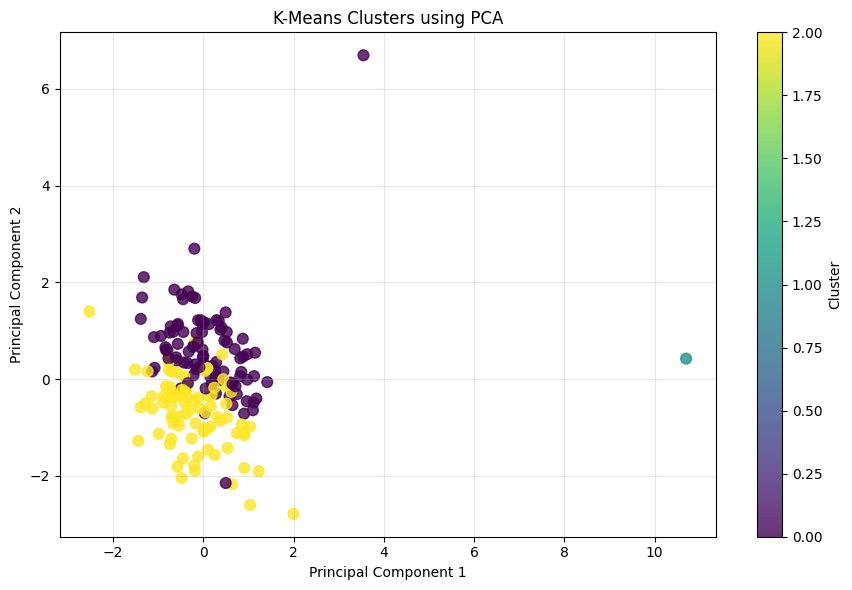

In [45]:
# Create a scatter plot using the two principal components

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_clusters,
    cmap='viridis',
    s=60,
    alpha=0.8
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters using PCA')

plt.colorbar(
    scatter,
    label='Cluster'
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Hierarchical

In [46]:
from sklearn.cluster import AgglomerativeClustering

# Use the same number of clusters selected for K-Means
hierarchical_model = AgglomerativeClustering(
    n_clusters=k,
    linkage='ward'
)

# Create cluster labels
hierarchical_clusters = hierarchical_model.fit_predict(X_scaled)

# Add cluster labels to the dataset
df['Hierarchical_Cluster'] = hierarchical_clusters

df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn,Cluster,Hierarchical_Cluster,DBSCAN_Cluster,KMeans_Cluster
0,CUST-1020,22,23800,11,62.96,7,20.4,5,Monthly,Bank Transfer,North,Standard,Yes,0,0,-1,0
1,CUST-1043,35,69400,17,75.63,6,17.5,9,Monthly,Bank Transfer,South,Basic,Yes,0,0,-1,0
2,CUST-1157,55,64400,49,92.85,3,21.6,1,Monthly,Upi,West,Basic,Yes,2,0,-1,2
3,CUST-1112,36,80000,9,85.67,0,34.3,9,Monthly,Upi,South,Standard,Yes,0,0,-1,0
4,CUST-1149,41,95700,51,60.77,1,23.7,9,Monthly,Debit Card,West,Premium,Yes,0,0,-1,0


In [47]:
from sklearn.metrics import silhouette_score

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_clusters
)

print(
    "Hierarchical Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

print(
    "Hierarchical Silhouette Score (%):",
    round(hierarchical_silhouette * 100, 2),
    "%"
)

Hierarchical Silhouette Score: 0.7194
Hierarchical Silhouette Score (%): 71.94 %


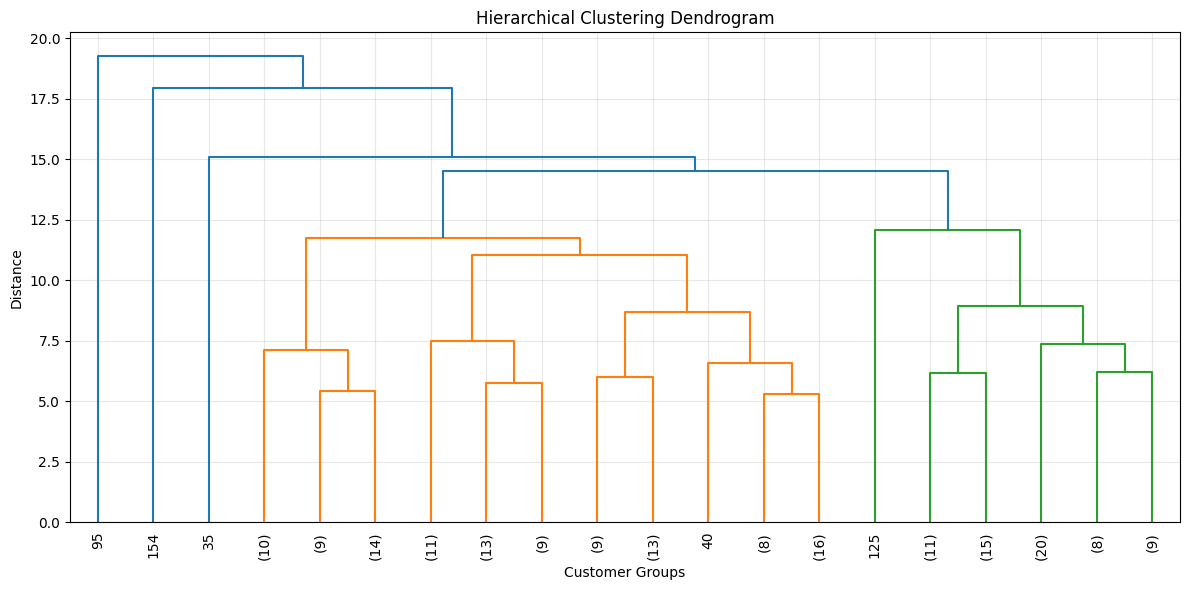

In [48]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Create the linkage matrix
linkage_matrix = linkage(
    X_scaled,
    method='ward'
)

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.xlabel('Customer Groups')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
from sklearn.decomposition import PCA

# Reduce the scaled data to 2 principal components
pca = PCA(n_components=2)

X_pca_hierarchical = pca.fit_transform(X_scaled)

# Display explained variance
print(
    "PC1 Explained Variance:",
    round(pca.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "PC2 Explained Variance:",
    round(pca.explained_variance_ratio_[1] * 100, 2),
    "%"
)

print(
    "Total Explained Variance:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

PC1 Explained Variance: 13.31 %
PC2 Explained Variance: 12.93 %
Total Explained Variance: 26.24 %


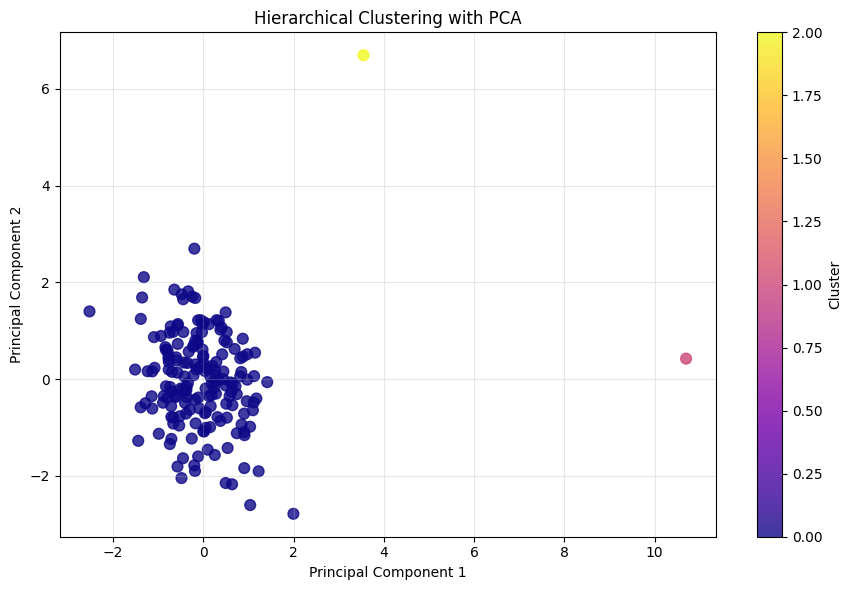

In [50]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca_hierarchical[:, 0],
    X_pca_hierarchical[:, 1],
    c=hierarchical_clusters,
    cmap='plasma',
    s=60,
    alpha=0.8
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Hierarchical Clustering with PCA')

plt.colorbar(
    scatter,
    label='Cluster'
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## DBSCAN

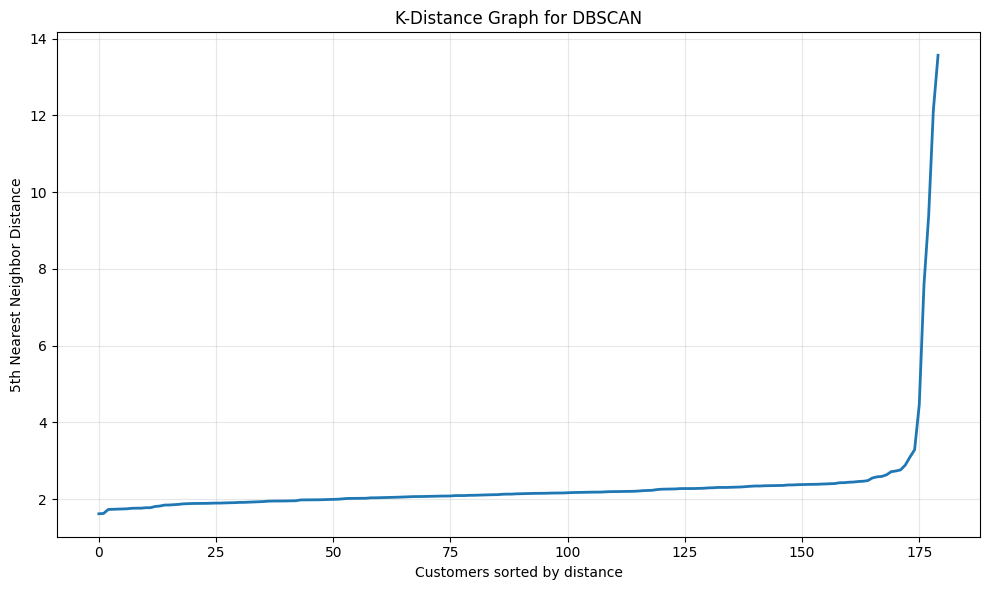

In [51]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Number of neighbors
k = 5

# Find the nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

# Calculate distances
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Take the distance to the 5th nearest neighbor
k_distances = distances[:, k - 1]

# Sort distances
k_distances = np.sort(k_distances)

# Plot K-Distance Graph
plt.figure(figsize=(10, 6))

plt.plot(
    k_distances,
    linewidth=2
)

plt.xlabel('Customers sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Graph for DBSCAN')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
from sklearn.cluster import DBSCAN

# Create DBSCAN model
dbscan_model = DBSCAN(
    eps=0.5,
    min_samples=5
)

# Perform clustering using StandardScaler data
dbscan_clusters = dbscan_model.fit_predict(X_scaled)

# Store cluster labels
df['DBSCAN_Cluster'] = dbscan_clusters

# Display the first 5 rows
df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn,Cluster,Hierarchical_Cluster,DBSCAN_Cluster,KMeans_Cluster
0,CUST-1020,22,23800,11,62.96,7,20.4,5,Monthly,Bank Transfer,North,Standard,Yes,0,0,-1,0
1,CUST-1043,35,69400,17,75.63,6,17.5,9,Monthly,Bank Transfer,South,Basic,Yes,0,0,-1,0
2,CUST-1157,55,64400,49,92.85,3,21.6,1,Monthly,Upi,West,Basic,Yes,2,0,-1,2
3,CUST-1112,36,80000,9,85.67,0,34.3,9,Monthly,Upi,South,Standard,Yes,0,0,-1,0
4,CUST-1149,41,95700,51,60.77,1,23.7,9,Monthly,Debit Card,West,Premium,Yes,0,0,-1,0


In [53]:
from sklearn.metrics import silhouette_score

# Remove DBSCAN noise points (-1)
mask = dbscan_clusters != -1

# Calculate silhouette score only when at least 2 clusters exist
if len(set(dbscan_clusters[mask])) > 1:

    dbscan_silhouette = silhouette_score(
        X_scaled[mask],
        dbscan_clusters[mask]
    )

    print(
        "DBSCAN Silhouette Score:",
        round(dbscan_silhouette, 4)
    )

    print(
        "DBSCAN Silhouette Score (%):",
        round(dbscan_silhouette * 100, 2),
        "%"
    )

else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score cannot be calculated.


In [54]:
from sklearn.decomposition import PCA

# Reduce the StandardScaler data to 2 components for visualization
pca_dbscan = PCA(n_components=2)

X_pca_dbscan = pca_dbscan.fit_transform(X_scaled)

# Display explained variance
print(
    "PC1 Explained Variance:",
    round(pca_dbscan.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "PC2 Explained Variance:",
    round(pca_dbscan.explained_variance_ratio_[1] * 100, 2),
    "%"
)

print(
    "Total Explained Variance:",
    round(pca_dbscan.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

PC1 Explained Variance: 13.31 %
PC2 Explained Variance: 12.93 %
Total Explained Variance: 26.24 %


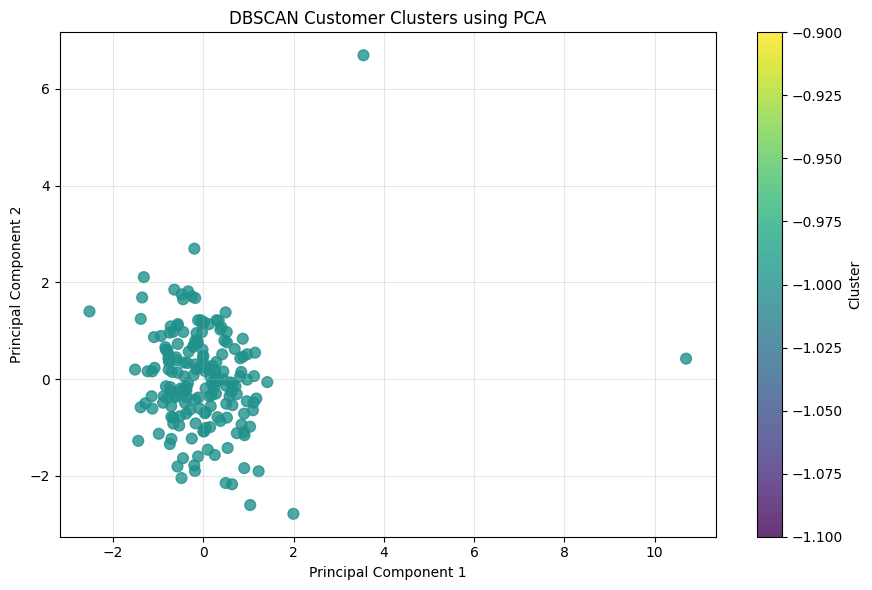

In [55]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca_dbscan[:, 0],
    X_pca_dbscan[:, 1],
    c=dbscan_clusters,
    cmap='viridis',
    s=60,
    alpha=0.8
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Customer Clusters using PCA')

plt.colorbar(
    scatter,
    label='Cluster'
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

PCA

In [56]:
from sklearn.decomposition import PCA

# Create PCA with 2 components
pca = PCA(n_components=2)

# Transform the scaled data into 2 principal components
X_pca = pca.fit_transform(X_scaled)

# Check the new shape
X_pca.shape

(180, 2)

In [57]:
# Explained variance of each principal component
print("PC1 Explained Variance:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2 Explained Variance:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")

# Total variance explained by the two components
print(
    "Total Explained Variance:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

PC1 Explained Variance: 13.31 %
PC2 Explained Variance: 12.93 %
Total Explained Variance: 26.24 %


C:\Users\nani8\AppData\Local\Temp\ipykernel_36312\4182134160.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


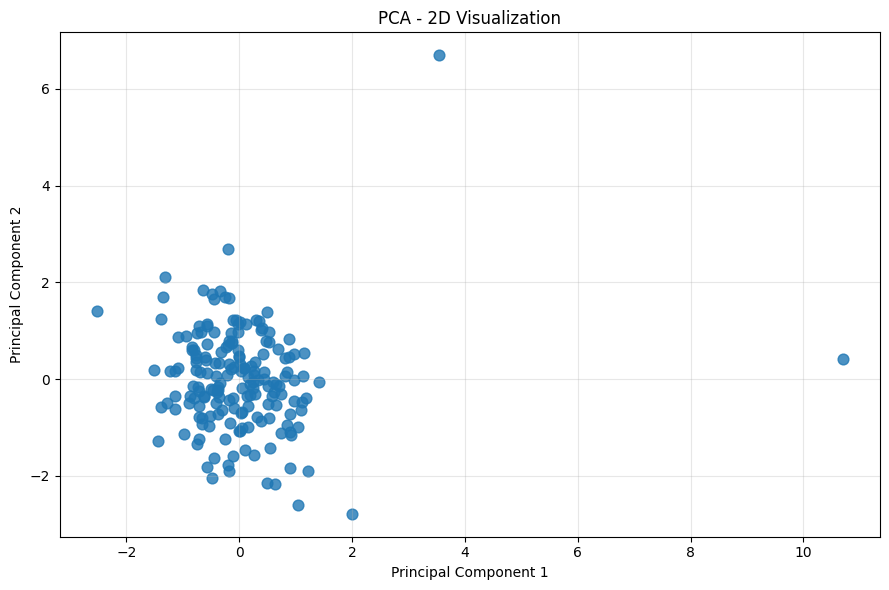

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    cmap='viridis',
    s=60,
    alpha=0.8
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - 2D Visualization')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

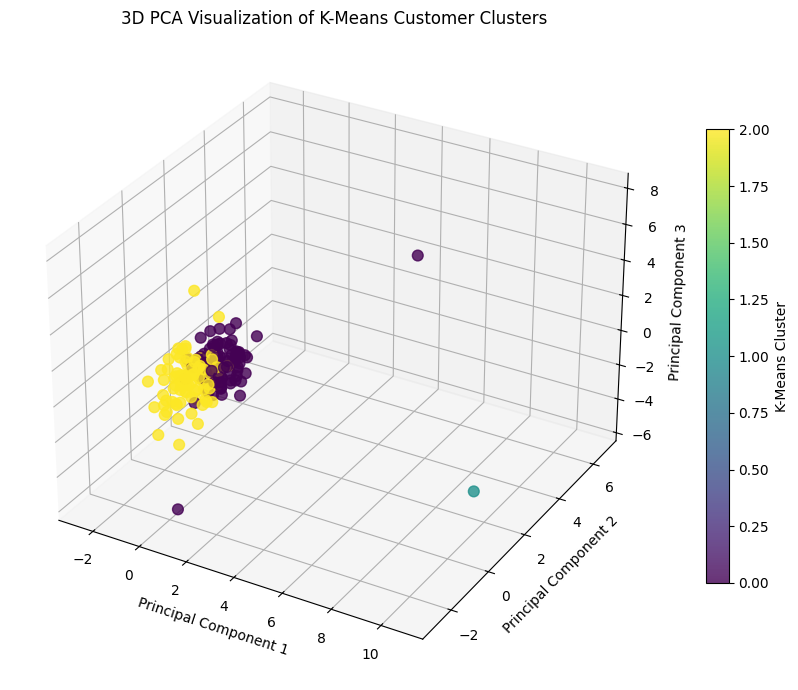

In [59]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create PCA with 3 components
pca_3d = PCA(n_components=3)

# Transform the scaled data into 3 principal components
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Create 3D graph
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points
scatter = ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=kmeans_clusters,
    cmap='viridis',
    s=60,
    alpha=0.8
)

# Labels
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

ax.set_title('3D PCA Visualization of K-Means Customer Clusters')

# Show cluster legend/colorbar
fig.colorbar(scatter, ax=ax, label='K-Means Cluster', shrink=0.7)

plt.tight_layout()
plt.show()

Apriori association rule

In [61]:
# Install mlxtend
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 10.0 MB/s  0:00:00


In [62]:
# Import required libraries
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

In [63]:
# Select categorical columns from the dataset
categorical_columns = df.select_dtypes(exclude='number').columns

# View the categorical columns
categorical_columns

Index(['Customer_ID', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type',
       'Churn'],
      dtype='object')

In [64]:
# Create a transaction-style dataset
transactions = pd.get_dummies(
    df[categorical_columns],
    dtype=int
)

# View the transaction data
transactions.head()

,Customer_ID_CUST-1001,Customer_ID_CUST-1002,Customer_ID_CUST-1003,Customer_ID_CUST-1004,Customer_ID_CUST-1005,Customer_ID_CUST-1006,Customer_ID_CUST-1007,Customer_ID_CUST-1008,Customer_ID_CUST-1009,Customer_ID_CUST-1010,...,Payment_Method_Upi,Region_East,Region_North,Region_South,Region_West,Plan_Type_Basic,Plan_Type_Premium,Plan_Type_Standard,Churn_No,Churn_Yes
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,1,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,1,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,1


In [65]:
# Find frequent itemsets using Apriori
frequent_itemsets = apriori(
    transactions,
    min_support=0.05,
    use_colnames=True
)

# Display frequent itemsets
frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(20)

c:\Users\nani8\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
2,0.577778,(Contract_Type_Monthly)
13,0.522222,(Plan_Type_Standard)
15,0.522222,(Churn_Yes)
14,0.477778,(Churn_No)
44,0.361111,"(Contract_Type_Monthly, Churn_Yes)"
0,0.288889,(Contract_Type_1 Year)
42,0.288889,"(Plan_Type_Standard, Contract_Type_Monthly)"
8,0.283333,(Region_North)
99,0.277778,"(Plan_Type_Standard, Churn_No)"
9,0.272222,(Region_South)


In [66]:
# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.5
)

# Display important columns
rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].sort_values(
    by='lift',
    ascending=False
).head(20)

,antecedents,consequents,support,confidence,lift
120,"(Contract_Type_Monthly, Region_North, Churn_Yes)",(Plan_Type_Basic),0.066667,0.545455,2.088975
39,"(Region_East, Churn_No)",(Contract_Type_1 Year),0.050000,0.562500,1.947115
119,"(Contract_Type_Monthly, Plan_Type_Basic, Regio...",(Churn_Yes),0.066667,0.923077,1.767594
122,"(Plan_Type_Basic, Region_North)","(Contract_Type_Monthly, Churn_Yes)",0.066667,0.631579,1.748988
48,"(Payment_Method_Credit Card, Region_South)",(Contract_Type_Monthly),0.050000,1.000000,1.730769
36,"(Plan_Type_Standard, Region_East)",(Contract_Type_1 Year),0.050000,0.500000,1.730769
2,(Contract_Type_2 Year),(Churn_No),0.105556,0.826087,1.729019
125,"(Region_South, Contract_Type_Monthly, Churn_No)",(Plan_Type_Standard),0.061111,0.846154,1.620295
79,"(Contract_Type_Monthly, Plan_Type_Basic)",(Churn_Yes),0.144444,0.838710,1.606040
121,"(Plan_Type_Basic, Region_North, Churn_Yes)",(Contract_Type_Monthly),0.066667,0.923077,1.597633


In [67]:
# Select strong association rules
strong_rules = rules[
    (rules['confidence'] >= 0.5) &
    (rules['lift'] > 1)
]

# Display strong rules
strong_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].sort_values(
    by='lift',
    ascending=False
)

,antecedents,consequents,support,confidence,lift
120,"(Contract_Type_Monthly, Region_North, Churn_Yes)",(Plan_Type_Basic),0.066667,0.545455,2.088975
39,"(Region_East, Churn_No)",(Contract_Type_1 Year),0.050000,0.562500,1.947115
119,"(Contract_Type_Monthly, Plan_Type_Basic, Regio...",(Churn_Yes),0.066667,0.923077,1.767594
122,"(Plan_Type_Basic, Region_North)","(Contract_Type_Monthly, Churn_Yes)",0.066667,0.631579,1.748988
48,"(Payment_Method_Credit Card, Region_South)",(Contract_Type_Monthly),0.050000,1.000000,1.730769
...,...,...,...,...,...
25,(Region_East),(Plan_Type_Standard),0.100000,0.529412,1.013767
26,(Region_East),(Churn_Yes),0.100000,0.529412,1.013767
6,(Payment_Method_Upi),(Contract_Type_Monthly),0.155556,0.583333,1.009615
47,"(Payment_Method_Bank Transfer, Churn_Yes)",(Contract_Type_Monthly),0.077778,0.583333,1.009615
